In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
def parse_line(line):
    pairs = line.strip().split(',')
    data = {}
    for pair in pairs:
        if ':' in pair:
            key, value = pair.split(':', 1)
            data[key.strip()] = float(value.strip())
    return data

In [45]:
def load_df(fps, df_ref: str=None):
    fp1, fp2 = fps[0], fps[1]
    data = []
    with open(fp1, 'r') as file:
        for line in file:
            if line.strip():  # Skip empty lines
                parsed_data = parse_line(line)
                data.append(parsed_data)
    df = pd.DataFrame(data)
    if df_ref:
        df["index_ref"] = df.apply(lambda x: df_ref, axis=1)

    data = []
    with open(fp2, 'r') as file:
        for line in file:
            if line.strip():  # Skip empty lines
                parsed_data = parse_line(line)
                data.append(parsed_data)
    df_temp = pd.DataFrame(data)
    df["while_time"] = df_temp["alg_while_ms"]

    return df
    

In [154]:
counter_coeffs = ["wcnt", "f1", "f2", "f3", "p1", "p3", "p5"]
# counter_coeffs = ["wcnt", "non_es", "f1", "f2", "f3", "p1", "p2", "p3", "p4", "p5", "p6", "p7", "br1", "br2"]

In [197]:
def index_res_pre_analysis(idx: pd.DataFrame, df_ref: str=None):
    idx_cols = idx.columns.to_list()
    # Initialize the MinMaxScaler
    scaler = MinMaxScaler()
    
    # Apply scaling only to the selected columns
    idx_normalized = idx.copy()
    idx_normalized[counter_coeffs] = scaler.fit_transform(idx[counter_coeffs])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))
    idx.boxplot(ax=ax1, column=counter_coeffs)
    idx_normalized.boxplot(ax=ax2, column=counter_coeffs)
    ax1.set_title('Coeffecients NOT normalized')
    ax2.set_title('Coeffecients normalized')
    fig.suptitle(idx["index_ref"][0])
    plt.show()

    # #######################################
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    ax.scatter(idx['termcnt'], idx['while_time'])
    # Add labels and title
    ax.set_xlabel('termcnt')
    ax.set_ylabel('total time')
    fig.suptitle("Term Count")
    plt.show()

    # #######################################
    X = idx[counter_coeffs]
    Y = idx["while_time"]
    TRAINING_SIZE = [0.5, 0.01]# in [0, 1]

    models = {}
    fig, axs = plt.subplots(1, len(TRAINING_SIZE), figsize=(16, 9))

    y_save = None
    for i, ts in enumerate(TRAINING_SIZE):
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1 - ts, random_state=42)
        # Initialize and train the regression model
        models[ts] = LinearRegression()
        models[ts].fit(X_train, Y_train)
        # Make predictions
        Y_pred = models[ts].predict(X_test)
        # Evaluate the model
        mse = mean_squared_error(Y_test, Y_pred)
        r2 = r2_score(Y_test, Y_pred)  
        print(f'TRAINING_SIZE: {ts} - Mean Squared Error: {mse} - R^2 Score: {r2}')
        axs[i].scatter(Y_test, Y_pred, color='blue')
        axs[i].plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linewidth=2)
        axs[i].set_xlabel('Actual')
        axs[i].set_ylabel('Predicted')
        axs[i].set_title(f'TRAINING SIZE: {ts}')
        y_save = (Y_test, Y_pred)
    
    fig.suptitle('Actual vs Predicted')
    plt.show()
    
    # #######################################
    dfqueries_list = ["termcnt <= 10", "termcnt > 10 and termcnt <= 20", "termcnt > 20 and termcnt <= 30", "termcnt > 30 and termcnt <= 40", "termcnt > 40 and termcnt <= 50", "termcnt > 50"]
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    # ax.scatter(Y_test, Y_pred, label="base")
    ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linewidth=2, label="groundtruth")
    for dfq in dfqueries_list:    
        X_s = idx.query(dfq)[counter_coeffs]
        if len(X_s) < 10:
            continue
        Y_s = idx.query(dfq)["while_time"]
        Y_s_pred = models[0.01].predict(X_s)
        ax.scatter(Y_s, Y_s_pred, label=dfq)
    # Add labels and title
    ax.legend()
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    plt.show()

    # #######################################
    idx["pred_time"] = models[0.01].predict(idx[counter_coeffs])
    idx["err"] = np.abs(idx["pred_time"] - idx["while_time"])
    err_queries = {"spladev2": ["err >= 100", "err < 100"], "unicoil_t5": ["err >= 50", "err < 50"]}
    print(idx["err"].describe())
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    # ax.scatter(Y_test, Y_pred, label="base")
    ax.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linewidth=2, label="groundtruth")
    for dfq in err_queries[df_ref]:    
        X_s = idx.query(dfq)[counter_coeffs]
        Y_s = idx.query(dfq)["while_time"]
        Y_s_pred = models[0.01].predict(X_s)
        ax.scatter(Y_s, Y_s_pred, label=dfq)
    # Add labels and title
    ax.legend()
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    plt.show

    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    compare_columns = counter_coeffs + ["termcnt"]
    num_columns = len(compare_columns)
    positions_group1 = range(1, num_columns + 1)  # Positions for first group
    positions_group2 = [x + 0.4 for x in positions_group1]  # Shift positions for second group

    idx_normalized["err"] = idx["err"]
    idx_normalized["termcnt"] = scaler.fit_transform(idx[["termcnt"]])
    idx_normalized.query(err_queries[df_ref][0]).boxplot(ax=ax, column=compare_columns, positions=positions_group1, widths=0.35, patch_artist=True, 
                                           boxprops=dict(facecolor='lightblue'), color='blue')
    idx_normalized.query(err_queries[df_ref][1]).boxplot(ax=ax, column=compare_columns, positions=positions_group2, widths=0.35, patch_artist=True, 
                                          boxprops=dict(facecolor='lightgreen'), color='green')
    # Adjust x-axis labels to show the correct column names
    ax.set_xticks([x + 0.2 for x in positions_group1])  # Set x-tick labels in between both boxplots
    ax.set_xticklabels(compare_columns)
    ax.legend([err_queries[df_ref][0], err_queries[df_ref][1]], loc='upper right',)
    plt.show()

    return y_save
    
    
    

    

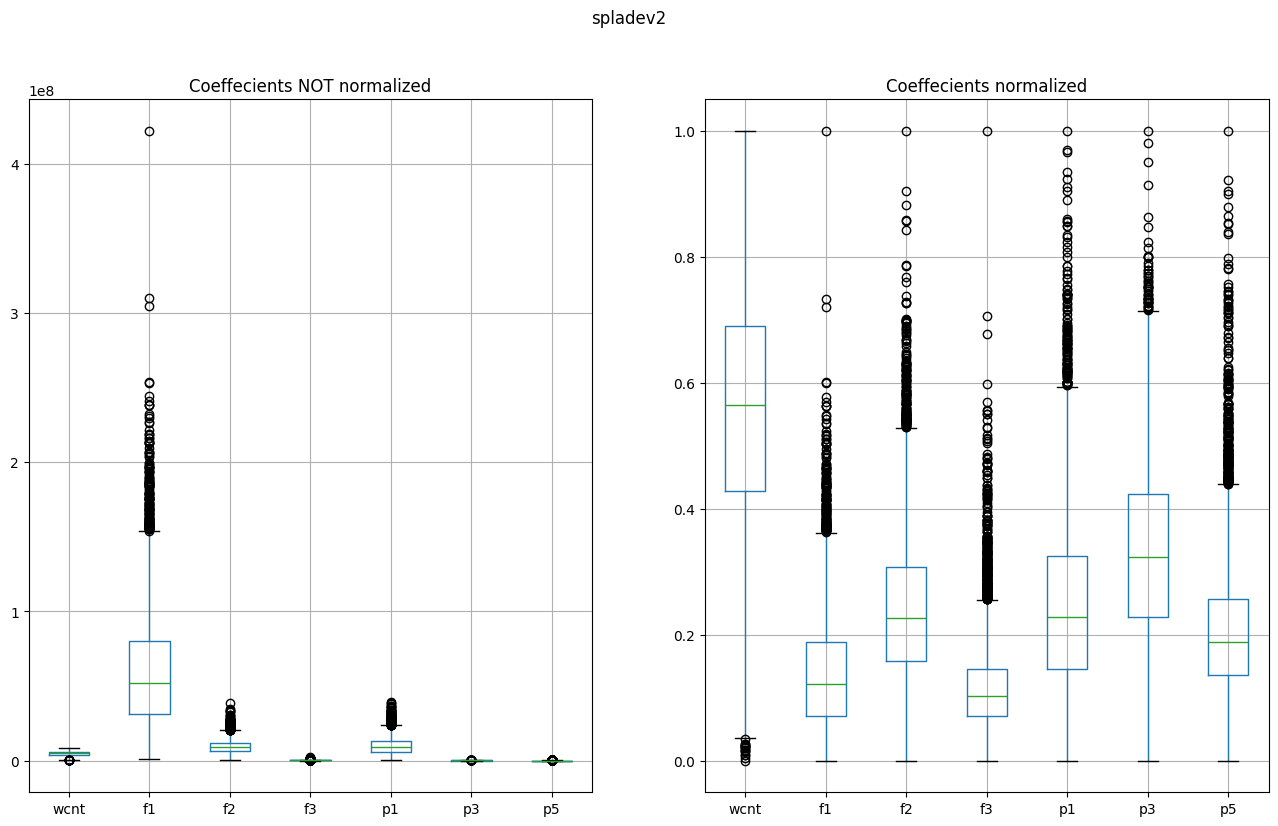

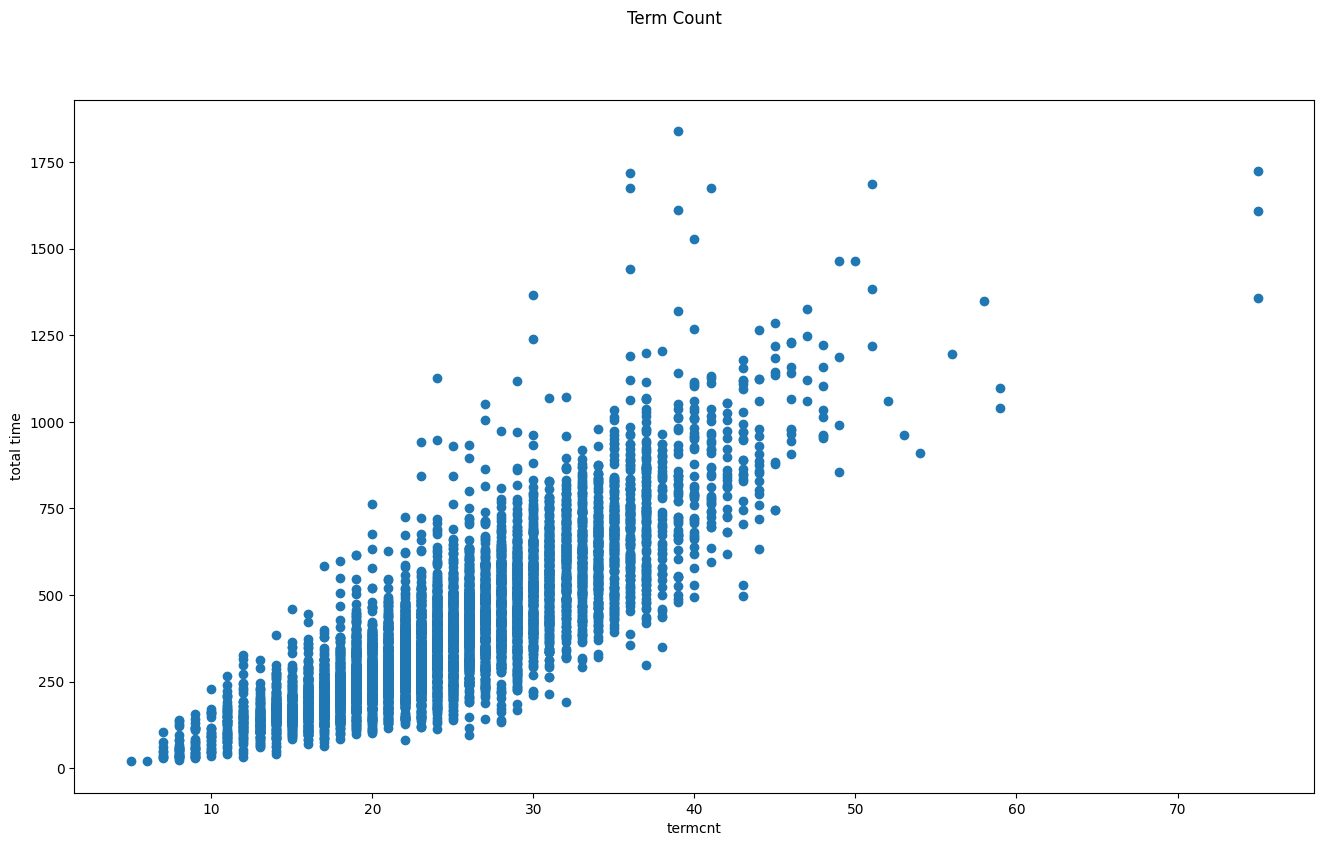

TRAINING_SIZE: 0.5 - Mean Squared Error: 2585.3388923150173 - R^2 Score: 0.9412770670105806
TRAINING_SIZE: 0.01 - Mean Squared Error: 2541.898091482321 - R^2 Score: 0.9442620753605436


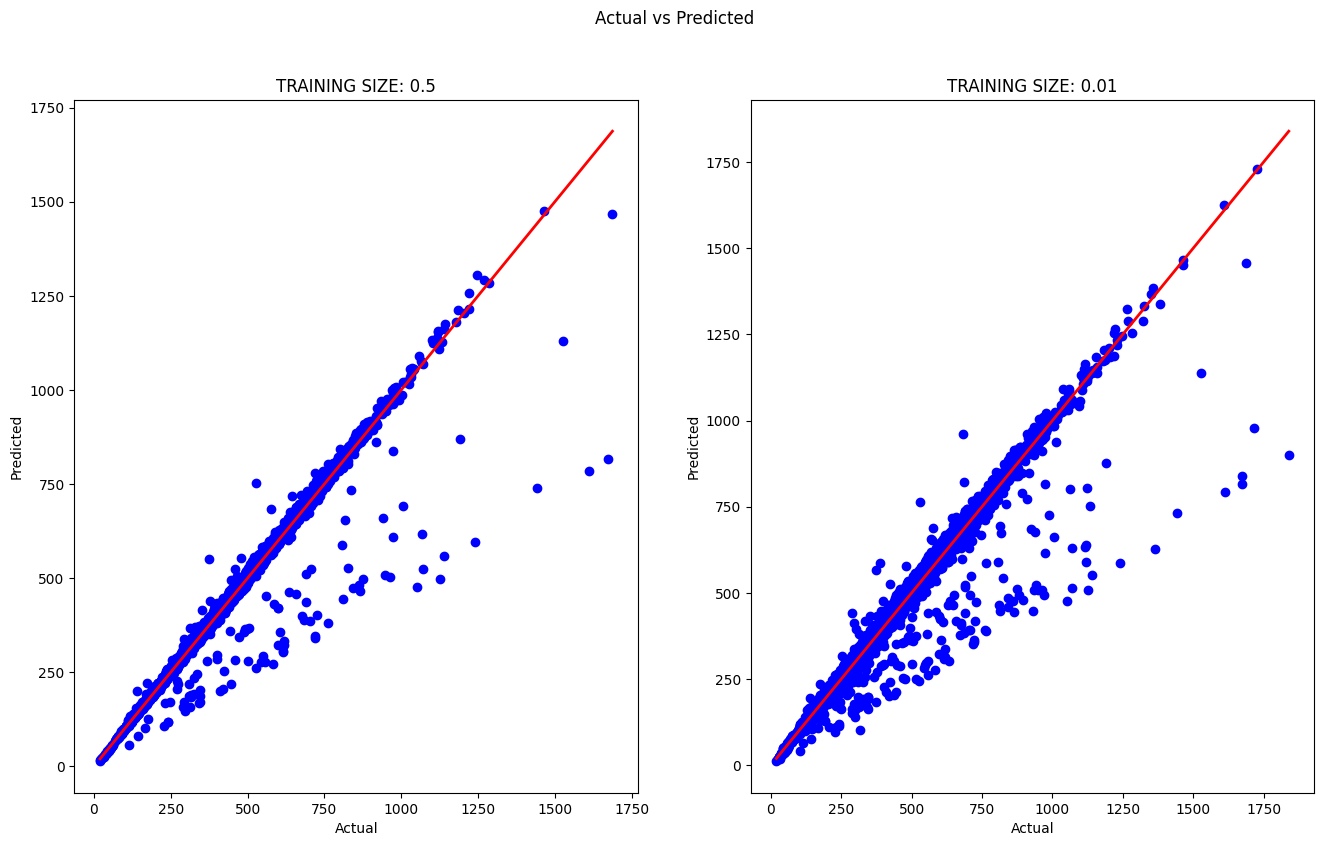

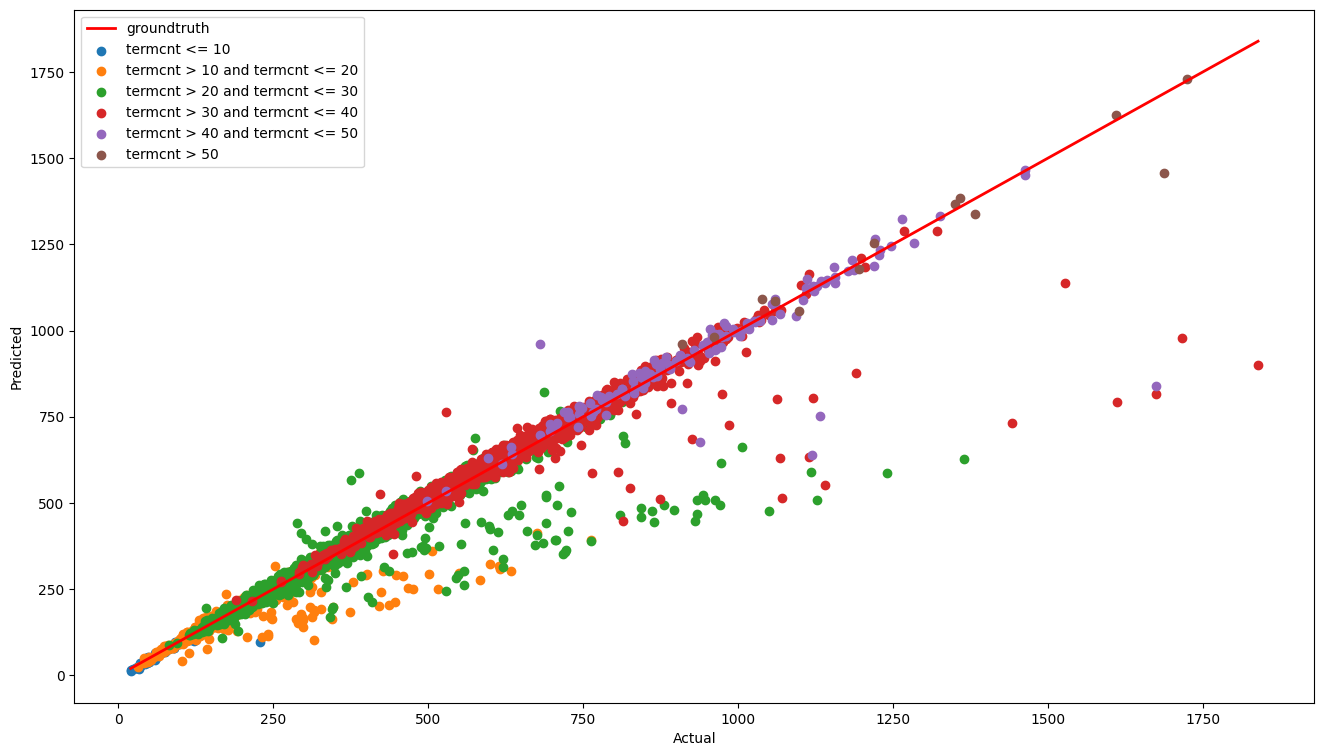

count    6980.000000
mean       18.497691
std        46.989126
min         0.000917
25%         4.830452
50%        10.460639
75%        18.709473
max       938.227716
Name: err, dtype: float64


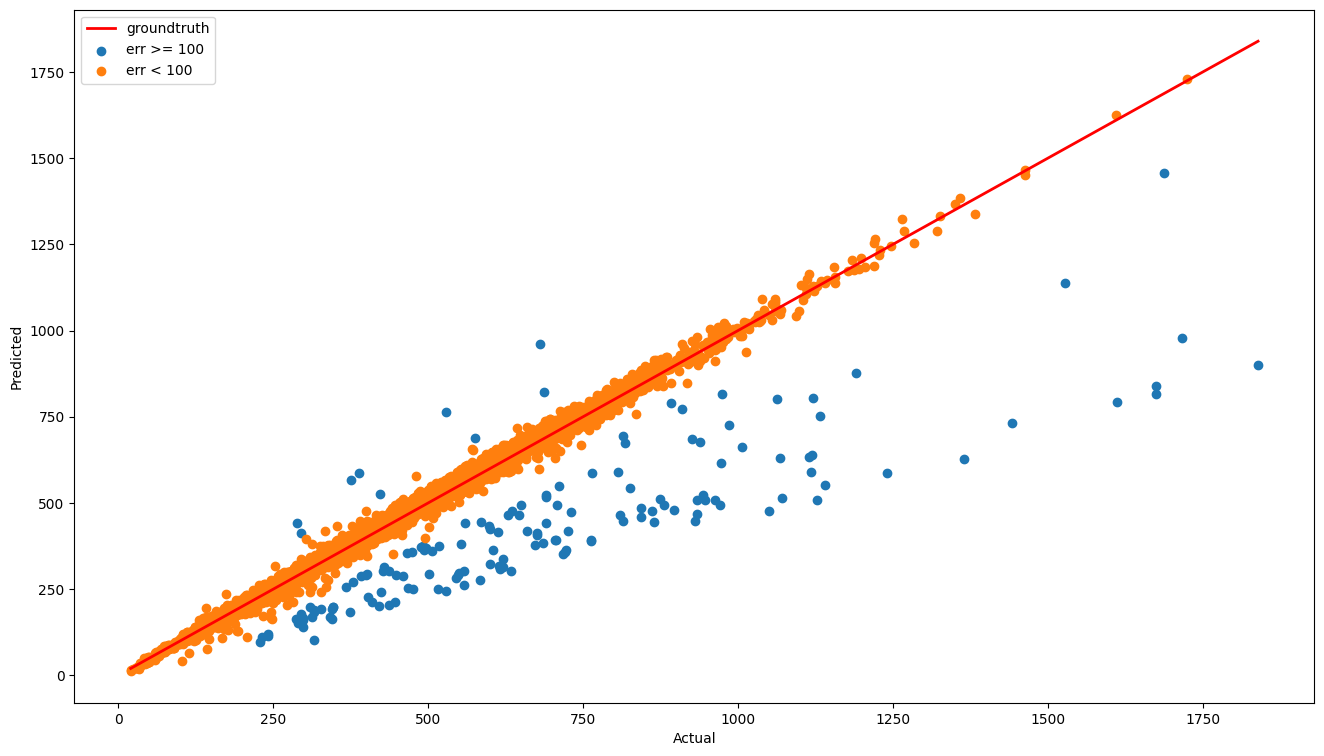

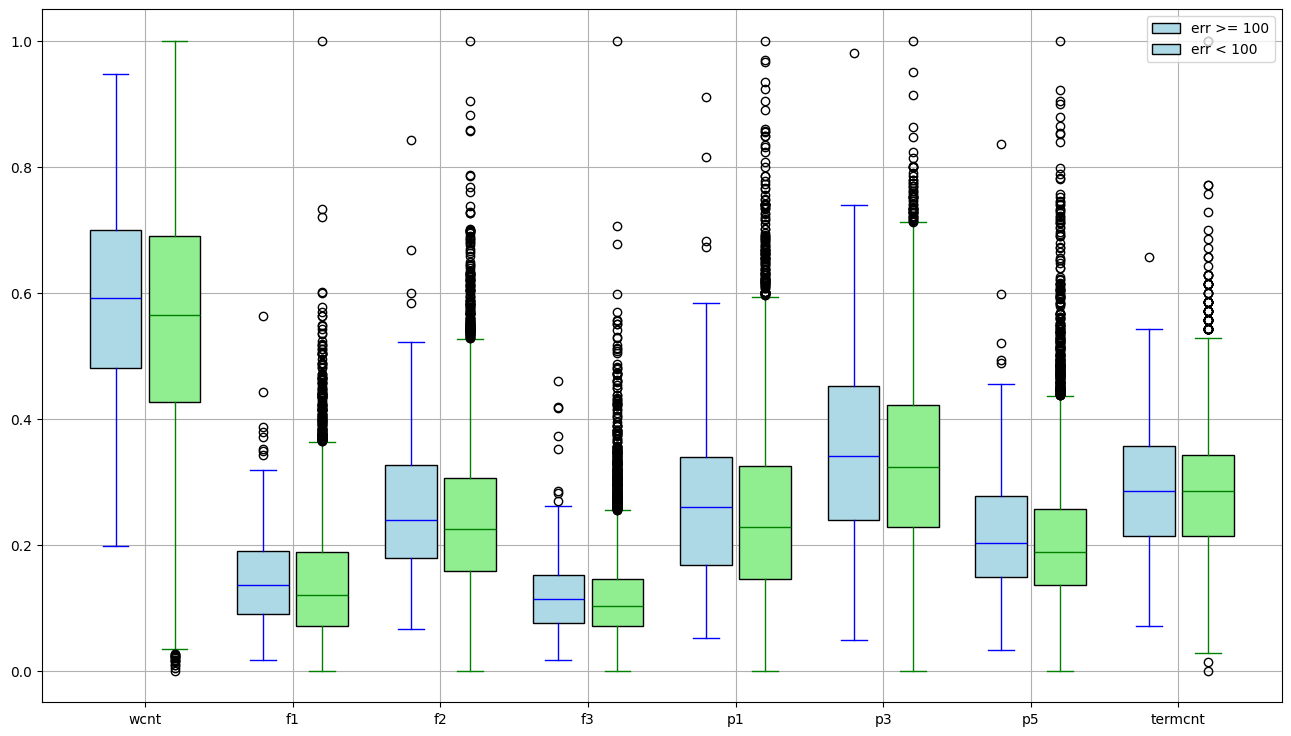

In [199]:
file_path = ["./logs/spladev2_counters_369535.dev.trec", "./logs/spladev2_timings_369466.dev.trec"]# Replace with your file path
spladev2_df = load_df(file_path, "spladev2")
y_save_spladev2 = index_res_pre_analysis(spladev2_df, "spladev2")


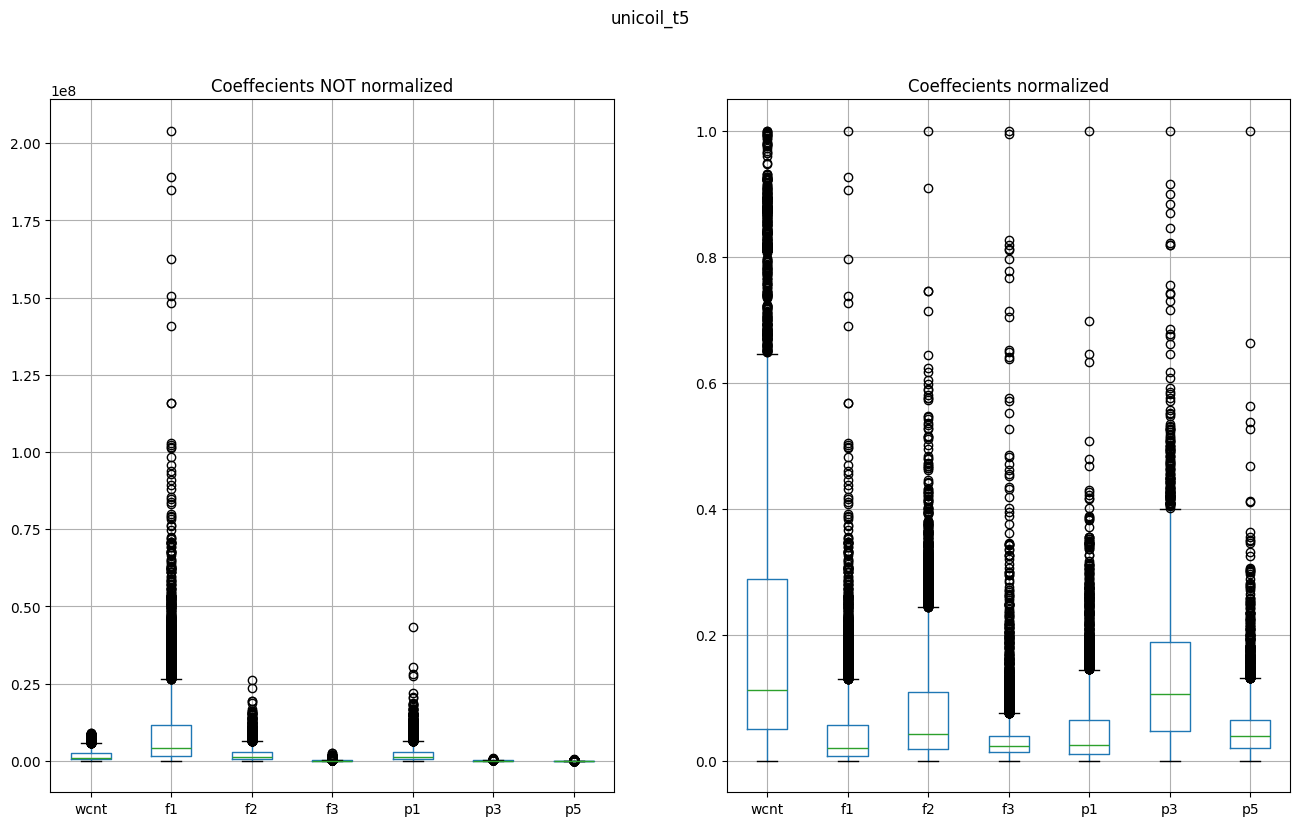

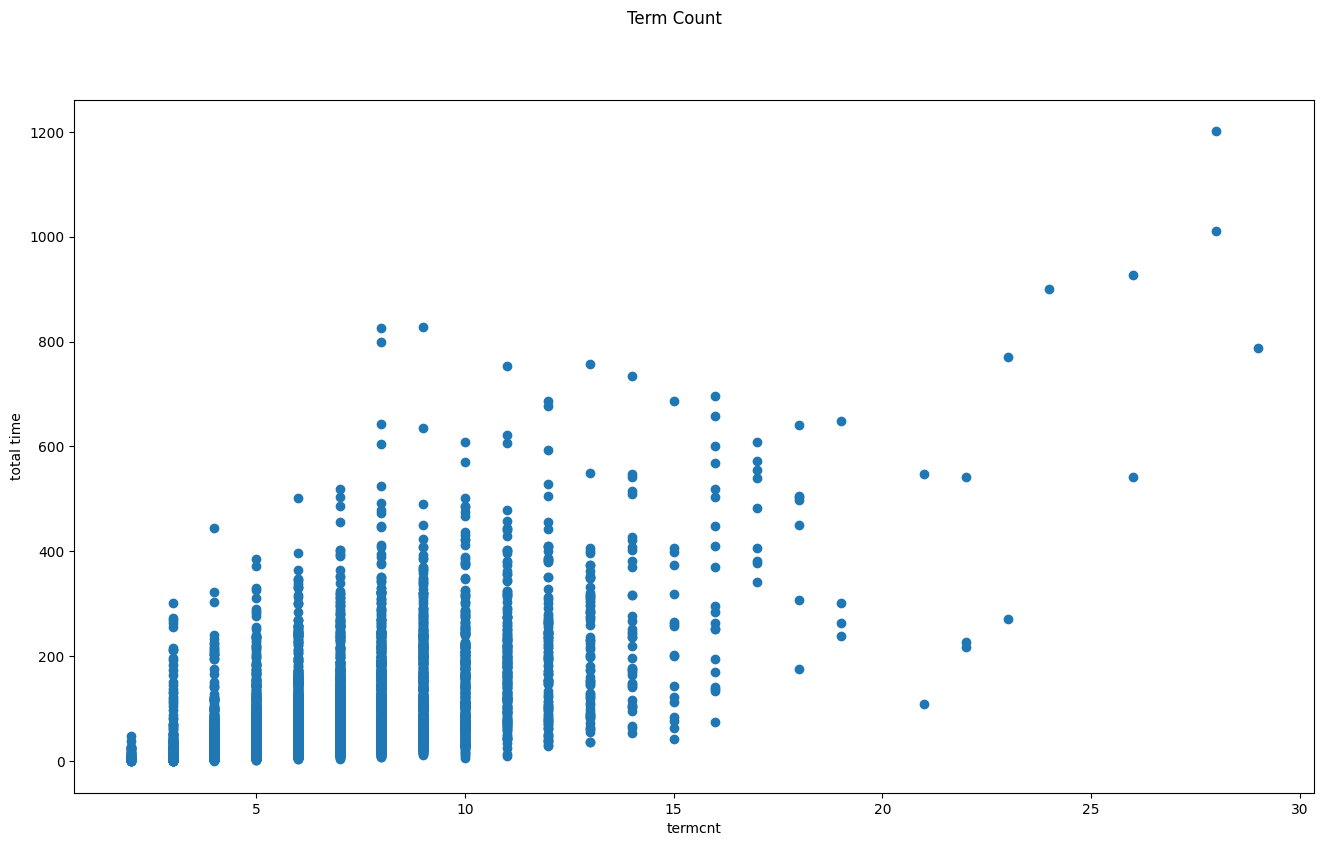

TRAINING_SIZE: 0.5 - Mean Squared Error: 761.2610260871886 - R^2 Score: 0.9088860336887978
TRAINING_SIZE: 0.01 - Mean Squared Error: 793.1185297234625 - R^2 Score: 0.9154721478871409


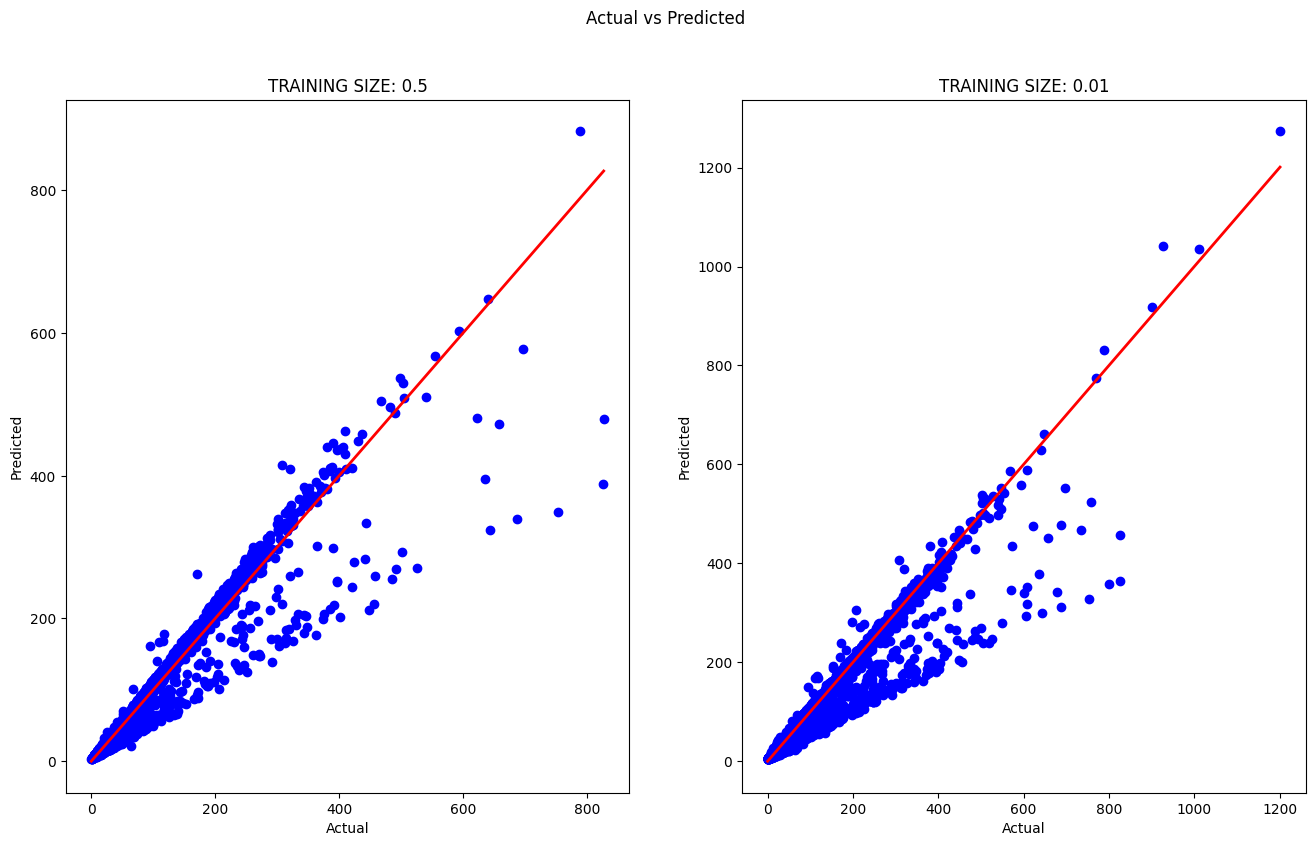

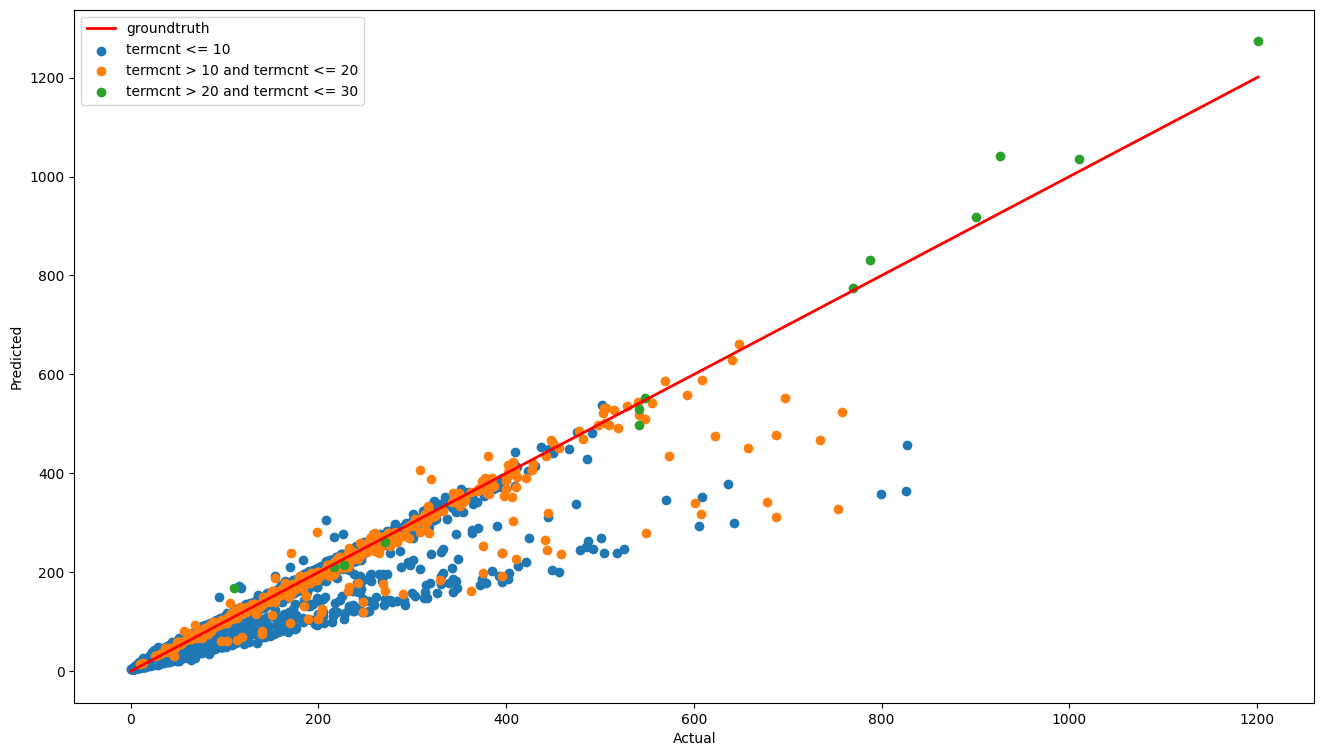

count    6980.000000
mean        9.912397
std        26.232123
min         0.000418
25%         2.474336
50%         4.149090
75%         7.355609
max       460.711871
Name: err, dtype: float64


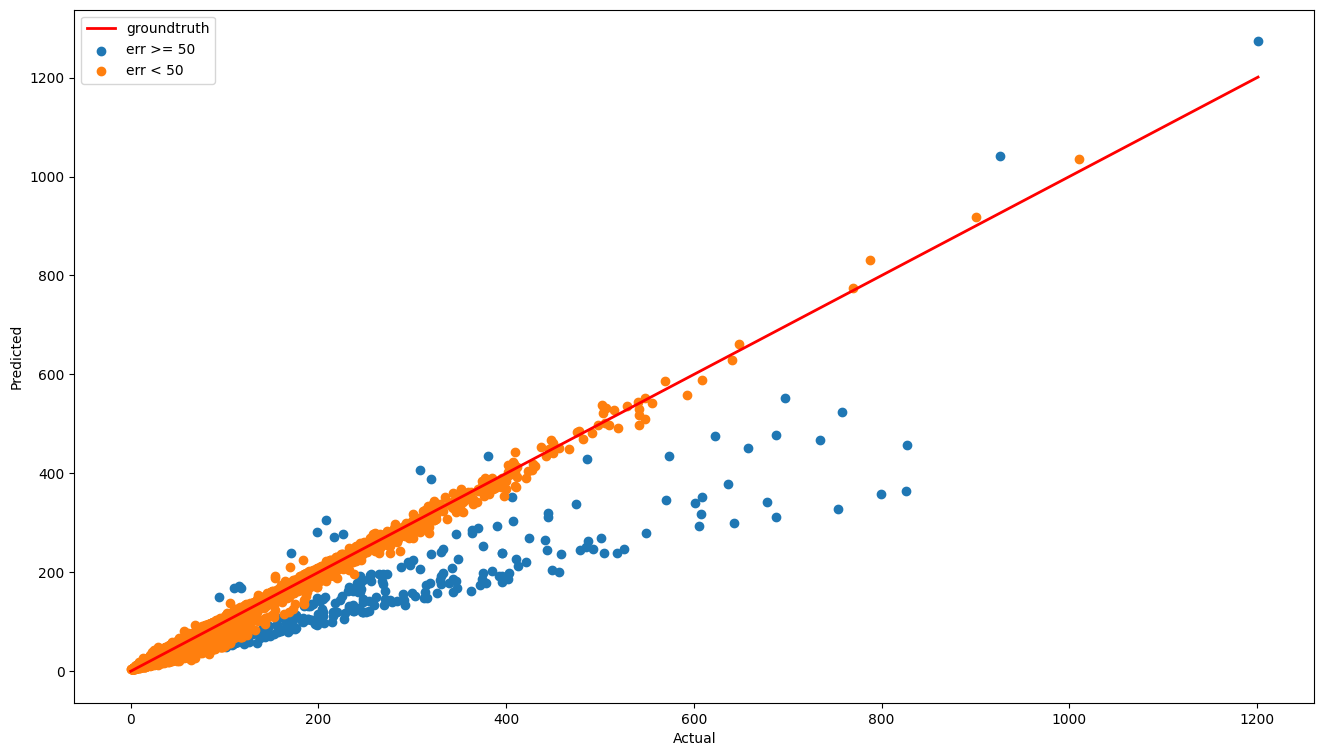

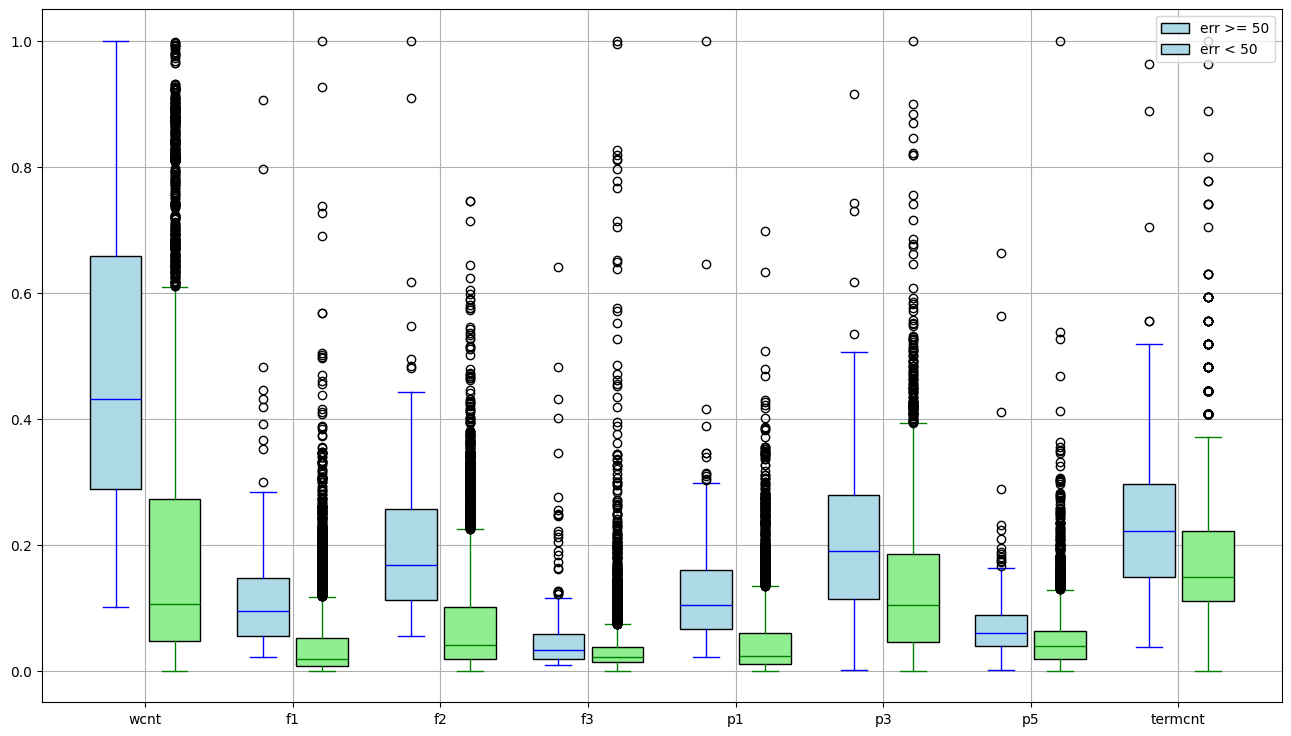

In [200]:
file_path = ["./logs/unicoil-t5_counters_369535.dev.trec", "./logs/unicoil-t5_timings_369466.dev.trec"]# Replace with your file path
unicoil_t5_df = load_df(file_path, "unicoil_t5")
y_save_unicoil_t5 = index_res_pre_analysis(unicoil_t5_df, "unicoil_t5")

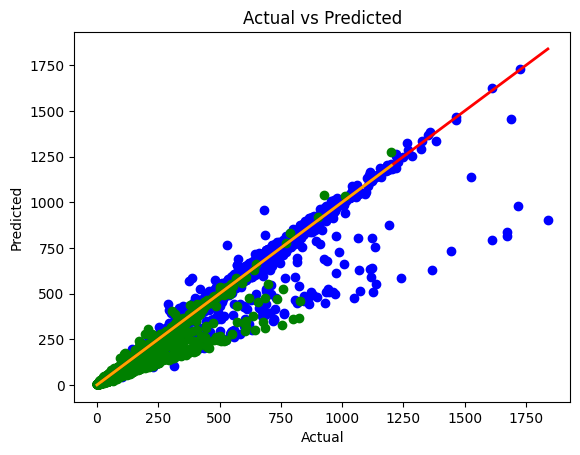

In [201]:
y_test_splade, y_pred_splade = y_save_spladev2
y_test_unicoil_t5, y_pred_unicoil_t5 = y_save_unicoil_t5

# Plotting the results
plt.scatter(y_test_splade, y_pred_splade, color='blue')
plt.plot([min(y_test_splade), max(y_test_splade)], [min(y_test_splade), max(y_test_splade)], color='red', linewidth=2)

plt.scatter(y_test_unicoil_t5, y_pred_unicoil_t5, color='green')
plt.plot([min(y_test_unicoil_t5), max(y_test_unicoil_t5)], [min(y_test_unicoil_t5), max(y_test_unicoil_t5)], color='orange', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()